# EDA for thesis

Graph-based optimizations of public transit routes

Data source: [GTFS realtime vehicle positions, Lviv Open Data](https://opendata.city-adm.lviv.ua/dataset/lviv-public-transport-gtfs-real-time/resource/d45fd95a-ffc9-45b1-be05-52012707d51f?inner_span=True)

[GTFS columns reference](https://gtfs.org/documentation/schedule/reference/)

## Installing dependencies

In [1]:
%pip install gtfs_kit osmnx numpy polars geopandas pyarrow scipy contextily folium mapclassify networkx matplotlib seaborn --quiet

# Export to HTML
%pip install -U notebook jupyter-client pyzmq --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Constants

In [2]:
from pathlib import Path
import geopandas as gpd
from shapely.geometry import LineString, Point
import matplotlib.pyplot as plt
import networkx as nx
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist

FOLDER_PATH = Path("../static")
DELIMITER = "-" * 20
ALPHA_PREFIX_REGEX = r"^\D+"

GTFS_ROUTE_TYPES = {
    "0": "Tram, Streetcar, Light rail",
    "1": "Subway, Metro",
    "2": "Rail",
    "3": "Bus",
    "4": "Ferry",
    # street-level rail cars where the cable runs beneath the vehicle
    "5": "Cable tram",
    # e.g., gondola lift, aerial tramway
    "6": "Aerial lift, suspended cable car",
    "7": "Funicular",
    "11": "Trolleybus",
    "12": "Monorail",
}
MODE_COLORS = {0: "#C1272D", 11: "#1B6CA8", 3: "#8A8F98"}
MODE_NAMES_UA = {0: "Трамвай", 11: "Тролейбус", 3: "Автобус"}


def partial_gtfs_route_types(route_types: list[str]) -> dict[str, str]:
    """
    Returns a dictionary of GTFS route types for the given list of route types.
    """
    return {k: v for k, v in GTFS_ROUTE_TYPES.items() if k in route_types}


DAYS_INDICES = {
    "monday": 0,
    "tuesday": 1,
    "wednesday": 2,
    "thursday": 3,
    "friday": 4,
    "saturday": 5,
    "sunday": 6,
}

OUT = Path("out")
OUT.mkdir(exist_ok=True)

## GTFS datasets samples

In [3]:
import polars as pl


print("Static GTFS info directory:", FOLDER_PATH.resolve(), end='\n\n')
dataframes = {
    f.name.split(".")[0]: pl.read_csv(f.resolve(), infer_schema_length=None)
    for f in FOLDER_PATH.iterdir() if f.is_file()
}

with pl.Config(tbl_formatting="MARKDOWN") as cfg:
    cfg.set_tbl_cols(-1)
    cfg.set_tbl_rows(-1)

    for name, df in dataframes.items():
        print(DELIMITER, name, DELIMITER, end='\n\n')

        print('Sample')
        print(df.head(3), end='\n\n')

Static GTFS info directory: /home/rojikaru/Projects/gtfs-tryout/static

-------------------- agency --------------------

Sample
shape: (3, 8)
| agency_id | agency_nam | agency_url | agency_tim | agency_la | agency_ph | agency_fa | agency_em |
| ---       | e          | ---        | ezone      | ng        | one       | re_url    | ail       |
| i64       | ---        | str        | ---        | ---       | ---       | ---       | ---       |
|           | str        |            | str        | str       | str       | str       | str       |
|-----------|------------|------------|------------|-----------|-----------|-----------|-----------|
| 31        | Міра і К   | http://cit | Europe/Kie | uk        | null      | null      | null      |
|           |            | y-adm.lviv | v          |           |           |           |           |
|           |            | .ua/portal |            |           |           |           |           |
|           |            | …          |          

## Structural characteristics

Everything related to the definition of routes & stops - either averages or things that don't change throughout the week.

### Trips

#### Average wheelchair accessibility 

In [4]:
trips_df = dataframes["trips"]
avg_accessibility = (
    trips_df["wheelchair_accessible"]
    .value_counts()
    .with_columns(
        pl.col("count")
        .cast(pl.Float64)
        .map_batches(lambda s: s / s.sum())
        .alias("share")
    )
    .sort("wheelchair_accessible")
)

print(avg_accessibility)

shape: (2, 3)
┌───────────────────────┬───────┬──────────┐
│ wheelchair_accessible ┆ count ┆ share    │
│ ---                   ┆ ---   ┆ ---      │
│ i64                   ┆ u32   ┆ f64      │
╞═══════════════════════╪═══════╪══════════╡
│ 0                     ┆ 13711 ┆ 0.861568 │
│ 1                     ┆ 2203  ┆ 0.138432 │
└───────────────────────┴───────┴──────────┘


### Routes

#### Modes of transportation (route_types)

In [5]:
routes_df = dataframes["routes"]
type_col, name_col, prefix_col = (
    "route_type",
    "route_short_name",
    "route_short_name_prefix",
)
pl_type_col, pl_name_col, pl_prefix_col = (
    pl.col(type_col),
    pl.col(name_col),
    pl.col(prefix_col),
)

print("Total routes:", routes_df.shape[0], end="\n\n")

# route_type is assigned incorrectly for trolleybuses, should be 11
# https://gtfs.org/documentation/schedule/reference/#routestxt
print(DELIMITER, "Route types (original)", DELIMITER)
print(routes_df[type_col].value_counts().sort("count"), end="\n\n")

prefixes_df = routes_df.with_columns(
    pl_name_col.str.extract(ALPHA_PREFIX_REGEX, 0).alias(prefix_col)
)

print(DELIMITER, "Route types (inferred)", DELIMITER)
print(prefixes_df[prefix_col].value_counts().sort("count"), end="\n\n")

trolley_prefix, tram_prefix = "Тр", "Т"

assert (
    prefixes_df[prefix_col].null_count() == 0
), f"Regex parsing is broken (new route without an alpha prefix in {name_col}?)"
assert (
    prefixes_df.filter((pl_type_col == 0) & (pl_prefix_col == trolley_prefix)).shape[0]
    == 0
), "Trolleys aren't distinguished from trams"
assert (
    prefixes_df.filter((pl_type_col == 11) & (pl_prefix_col == tram_prefix)).shape[0]
    == 0
), "Trams aren't distinguished from trolleys"

prefixes_df = prefixes_df.with_columns(
    pl.when(pl_prefix_col == trolley_prefix)
    .then(11)
    .otherwise(pl_type_col)
    .alias(type_col)
)

routes_df = prefixes_df.drop(prefix_col)

print(DELIMITER, "Route types (corrected)", DELIMITER)
print(routes_df[type_col].value_counts().sort("count"))

Total routes: 72

-------------------- Route types (original) --------------------
shape: (2, 2)
┌────────────┬───────┐
│ route_type ┆ count │
│ ---        ┆ ---   │
│ i64        ┆ u32   │
╞════════════╪═══════╡
│ 0          ┆ 8     │
│ 3          ┆ 64    │
└────────────┴───────┘

-------------------- Route types (inferred) --------------------
shape: (3, 2)
┌─────────────────────────┬───────┐
│ route_short_name_prefix ┆ count │
│ ---                     ┆ ---   │
│ str                     ┆ u32   │
╞═════════════════════════╪═══════╡
│ Т                       ┆ 8     │
│ Тр                      ┆ 9     │
│ А                       ┆ 55    │
└─────────────────────────┴───────┘

-------------------- Route types (corrected) --------------------
shape: (3, 2)
┌────────────┬───────┐
│ route_type ┆ count │
│ ---        ┆ ---   │
│ i64        ┆ u32   │
╞════════════╪═══════╡
│ 0          ┆ 8     │
│ 11         ┆ 9     │
│ 3          ┆ 55    │
└────────────┴───────┘


#### Modes of transportation by agency

In [6]:
agency_df = dataframes["agency"]

routes_with_agency_df = routes_df.join(agency_df, on="agency_id", how="left")
assert (
    
    routes_df.shape[0] == routes_with_agency_df.shape[0]
), "LEFT JOIN with agency_df changed the number of rows, something is wrong"

crosstab_df = (
    routes_with_agency_df.pivot(
        values=type_col,
        index=["agency_id", "agency_name"],
        on=type_col,
        aggregate_function="len",
    )
).rename(partial_gtfs_route_types(["0", "3", "11"]))

print(crosstab_df, end="\n\n")

shape: (7, 5)
┌───────────┬───────────────────────┬─────┬─────────────────────────────┬────────────┐
│ agency_id ┆ agency_name           ┆ Bus ┆ Tram, Streetcar, Light rail ┆ Trolleybus │
│ ---       ┆ ---                   ┆ --- ┆ ---                         ┆ ---        │
│ i64       ┆ str                   ┆ u32 ┆ u32                         ┆ u32        │
╞═══════════╪═══════════════════════╪═════╪═════════════════════════════╪════════════╡
│ 31        ┆ Міра і К              ┆ 6   ┆ 0                           ┆ 0          │
│ 52        ┆ АТП-1                 ┆ 28  ┆ 0                           ┆ 0          │
│ 89        ┆ ЛКП Львівелектротранс ┆ 0   ┆ 8                           ┆ 9          │
│ 148       ┆ Фіакр-Львів           ┆ 6   ┆ 0                           ┆ 0          │
│ 32        ┆ Львівське АТП-14630   ┆ 6   ┆ 0                           ┆ 0          │
│ 327       ┆ ТОВ Епітранс          ┆ 5   ┆ 0                           ┆ 0          │
│ 10        ┆ Успіх БМ       

### Stop times [(reference)](https://gtfs.org/documentation/schedule/reference/#stop_timestxt)

#### Working hours

In [7]:
stop_times_df = dataframes["stop_times"]

min_arrival_time = stop_times_df.select(pl.col("arrival_time").min()).item()
max_departure_time = stop_times_df.select(pl.col("departure_time").max()).item()

print(f"Min arrival time: {min_arrival_time}")
print(f"Max departure time: {max_departure_time}")

# Do they contain arrival/departure times over 24:00:00?
stops_after_midnight_df = stop_times_df.filter(
    (pl.col("arrival_time").str.extract(r"^(\d+):", 1).cast(pl.Int64) >= 24)
    | (pl.col("departure_time").str.extract(r"^(\d+):", 1).cast(pl.Int64) >= 24)
)
assert (
    stops_after_midnight_df.shape[0] == 0
), "Stops after midnight found. Has curfew been lifted in Lviv? Or GTFS data is broken? Check the GTFS feed for the latest updates."

Min arrival time: 05:30:00
Max departure time: 23:50:00


#### Average stop counts per trip

In [8]:
trips_with_routes_df = trips_df.join(routes_with_agency_df, on="route_id", how="left")
assert (
    trips_df.shape[0] == trips_with_routes_df.shape[0]
), "LEFT JOIN with routes_with_agency_df changed the number of rows, something is wrong"

print(
    trips_with_routes_df.group_by(["agency_id", "agency_name"])
    .agg(
        [
            pl.mean("wheelchair_accessible").alias("wheelchair_accessible_share"),
            pl.count("trip_id").alias("total_trips"),
        ]
    )
    .sort("wheelchair_accessible_share", descending=True)
)

shape: (7, 4)
┌───────────┬───────────────────────┬─────────────────────────────┬─────────────┐
│ agency_id ┆ agency_name           ┆ wheelchair_accessible_share ┆ total_trips │
│ ---       ┆ ---                   ┆ ---                         ┆ ---         │
│ i64       ┆ str                   ┆ f64                         ┆ u32         │
╞═══════════╪═══════════════════════╪═════════════════════════════╪═════════════╡
│ 10        ┆ Успіх БМ              ┆ 0.637509                    ┆ 1349        │
│ 148       ┆ Фіакр-Львів           ┆ 0.187441                    ┆ 1051        │
│ 89        ┆ ЛКП Львівелектротранс ┆ 0.167337                    ┆ 4972        │
│ 52        ┆ АТП-1                 ┆ 0.056699                    ┆ 5538        │
│ 31        ┆ Міра і К              ┆ 0.0                         ┆ 1210        │
│ 327       ┆ ТОВ Епітранс          ┆ 0.0                         ┆ 798         │
│ 32        ┆ Львівське АТП-14630   ┆ 0.0                         ┆ 996         │
└─

In [9]:
stop_counts_df = (
    stop_times_df.group_by("trip_id")
    .agg(pl.count("stop_id").alias("stop_count"))
    .sort("stop_count", descending=True)
)
stop_counts_with_routes_df = stop_counts_df.join(
    trips_with_routes_df,
    on="trip_id",
    how="left",
    # TODO: change _name to _id
).select(["trip_id", "route_short_name", "agency_name", "stop_count"])
assert (
    stop_counts_df.shape[0] == stop_counts_with_routes_df.shape[0]
), "LEFT JOIN with trips_with_routes_df changed the number of rows, something is wrong"

stop_counts_with_routes_df = (
    # TODO: change _name to _id
    stop_counts_with_routes_df.group_by(["agency_name", "route_short_name"])
    .agg(
        [
            pl.mean("stop_count").alias("mean_stop_count"),
            pl.median("stop_count").alias("median_stop_count"),
            pl.count("trip_id").alias("total_trips"),
        ]
    )
    .sort("mean_stop_count", descending=True)
)

with pl.Config(tbl_formatting="MARKDOWN") as cfg:
    cfg.set_tbl_cols(-1)
    cfg.set_tbl_rows(-1)
    print(stop_counts_with_routes_df, end="\n\n")

shape: (72, 5)
| agency_name           | route_short_name | mean_stop_count | median_stop_count | total_trips |
| ---                   | ---              | ---             | ---               | ---         |
| str                   | str              | f64             | f64               | u32         |
|-----------------------|------------------|-----------------|-------------------|-------------|
| АТП-1                 | А47              | 52.015251       | 53.0              | 459         |
| Львівське АТП-14630   | А23              | 48.099206       | 46.0              | 252         |
| Міра і К              | А25              | 47.5            | 47.5              | 232         |
| АТП-1                 | А09              | 45.495549       | 44.0              | 337         |
| Фіакр-Львів           | А41              | 43.329949       | 42.0              | 197         |
| АТП-1                 | А61              | 42.830189       | 43.0              | 159         |
| Міра і К     

## Service levels

Things that may change throughout the week - schedules, accessibility, etc

### Date checks

In [10]:
from datetime import date

feed_info_df = dataframes["feed_info"]
calendar_df = dataframes["calendar"]
calendar_dates_df = dataframes["calendar_dates"]

service_id_col, agency_id_col = "service_id", "agency_id"

# Sanity check: do trip service IDs overlap with calendar service IDs?
trip_service_ids = set(trips_df[service_id_col].unique())
calendar_service_ids = set(calendar_df[service_id_col].unique())
assert (
    len(trip_service_ids & calendar_service_ids) > 0
), "No overlapping service IDs found between trips and calendar"
assert (
    len(trip_service_ids - calendar_service_ids) == 0
), "Some service IDs in trips are not found in calendar. Check the GTFS feed for the latest updates."

# Gate for calendar_dates.txt: no accident reporting when I was working on this notebook
assert (
    calendar_dates_df.shape[0] == 0
), "calendar_dates.txt is not empty. Check the GTFS feed for the latest updates."

# Get the feed start and end dates from the feed_info.txt file
feed_start_date = feed_info_df["feed_start_date"].first()
feed_end_date = feed_info_df["feed_end_date"].first()
print("Feed date range:", feed_start_date, "-", feed_end_date)


def service_ids_for_date(day_of_week: str, date_in_feed_range: int) -> list:
    """
    Get the service IDs that are active on that day.
    """

    assert (
        feed_start_date <= date_in_feed_range <= feed_end_date
    ), f"The date {date_in_feed_range} is not in the feed range {feed_start_date} - {feed_end_date}"

    day_of_week_idx = DAYS_INDICES[day_of_week.lower()]
    assert (
        date.fromisoformat(str(date_in_feed_range)).weekday() == day_of_week_idx
    ), f"The {day_of_week} date is not a {day_of_week}"
    print(f"Stats for {day_of_week}, {date_in_feed_range}:", end="\n\n")

    service_ids = (
        calendar_df.filter(
            (pl.col(day_of_week) == 1)
            & (pl.col("start_date") <= date_in_feed_range)
            & (pl.col("end_date") >= date_in_feed_range)
        )[service_id_col]
        .unique()
        .to_list()
    )
    assert len(service_ids) > 0, f"No service IDs found for that {day_of_week}"
    print("Service IDs active:", service_ids)
    return service_ids

Feed date range: 20260903 - 20270823


### Average daily trips stats

In [11]:
def average_stats_per_day(day_of_week: str, date_in_feed_range: int) -> None:
    service_ids = service_ids_for_date(day_of_week, date_in_feed_range)

    # Trips for the passed day of the week
    daily_trips_df = trips_df.filter(pl.col(service_id_col).is_in(service_ids)).join(
        routes_with_agency_df, on="route_id", how="left"
    )
    print("Number of trips:", daily_trips_df.shape[0])

    # Accessibility of trips on that day
    accessible_share = (
        daily_trips_df.select(pl.mean("wheelchair_accessible").alias("share"))
        .select(pl.col("share") * 100)
        .item()
    )
    assert 0 <= accessible_share <= 100, "Wheelchair accessible share is out of bounds"
    print(
        f"Average wheelchair accessible trips: {accessible_share:.2f}%",
        end="\n\n",
    )

    # Get the average accessibility by agency
    agency_accessibility = (
        daily_trips_df.group_by([agency_id_col, "agency_name"])
        .agg(
            [
                pl.mean("wheelchair_accessible").alias("wheelchair_accessible_share"),
                pl.count("trip_id").alias("total_trips"),

                # array of all service IDs for that agency
                pl.col(service_id_col).unique().alias("service_ids")
            ]
        )
        .sort("wheelchair_accessible_share", descending=True)
    )

    print("Average accessibility by agency:")
    print(agency_accessibility, end="\n\n")

    print(DELIMITER, end="\n\n")


average_stats_per_day("wednesday", 20260909)
average_stats_per_day("saturday", 20260912)
average_stats_per_day("sunday", 20260913)

Stats for wednesday, 20260909:

Service IDs active: [31, 63, 159, 191, 255]
Number of trips: 8629
Average wheelchair accessible trips: 13.62%

Average accessibility by agency:
shape: (7, 5)
┌───────────┬───────────────────────┬─────────────────────────────┬─────────────┬────────────────┐
│ agency_id ┆ agency_name           ┆ wheelchair_accessible_share ┆ total_trips ┆ service_ids    │
│ ---       ┆ ---                   ┆ ---                         ┆ ---         ┆ ---            │
│ i64       ┆ str                   ┆ f64                         ┆ u32         ┆ list[i64]      │
╞═══════════╪═══════════════════════╪═════════════════════════════╪═════════════╪════════════════╡
│ 10        ┆ Успіх БМ              ┆ 0.668721                    ┆ 649         ┆ [31]           │
│ 148       ┆ Фіакр-Львів           ┆ 0.189928                    ┆ 695         ┆ [31]           │
│ 89        ┆ ЛКП Львівелектротранс ┆ 0.161737                    ┆ 2671        ┆ [159, 31]      │
│ 52        ┆ АТП-

### Daily intervals per route

In [12]:
trips_with_routes_df = trips_df.join(routes_df, on="route_id", how="left")
stop_times_with_routes_df = stop_times_df.join(
    trips_with_routes_df, on="trip_id", how="left"
)


def route_intervals_per_day(day_of_week: str, date_in_feed_range: int) -> pl.DataFrame:
    service_ids = service_ids_for_date(day_of_week, date_in_feed_range)

    # First departures of each trip, in seconds from midnight
    # over("trip_id") computes the minimum within each trip, not across the entire table.
    first_departures = (
        stop_times_with_routes_df.filter(pl.col("service_id").is_in(service_ids))
        .filter(
            pl.col("stop_sequence") == pl.col("stop_sequence").min().over("trip_id")
        )
        # Convert to seconds since midnight
        .with_columns(
            pl.col("departure_time")
            .str.splitn(":", 3)
            .struct.rename_fields(["h", "m", "s"])
            .alias("t")
        )
        .with_columns(
            (
                pl.col("t").struct.field("h").cast(pl.Int32) * 3600
                + pl.col("t").struct.field("m").cast(pl.Int32) * 60
                + pl.col("t").struct.field("s").cast(pl.Int32)
            ).alias("departure_seconds")
        )
        .select(
            [
                "trip_id",
                "route_id",
                "route_short_name",
                "route_type",
                "direction_id",
                "departure_seconds",
            ]
        )
    )

    n_trips = first_departures.shape[0]
    print("First departures:", n_trips)
    assert (
        first_departures["trip_id"].n_unique() == n_trips
    ), "Більше ніж одне 'перше відправлення' на рейс — перевір stop_sequence"

    # route+direction sort and diff between adjacent departures
    intervals = (
        first_departures.sort("departure_seconds")
        .with_columns(
            pl.col("departure_seconds")
            .diff()
            .over(["route_id", "direction_id"])
            .alias("headway_seconds")
        )
        .drop_nulls("headway_seconds")  # first departure has no headway
        .filter(pl.col("headway_seconds") > 0)  # two trips in the same minute
    )

    # Median headway per route, regardless of direction
    by_route = (
        intervals.group_by(["route_id", "route_short_name", "route_type"])
        .agg(
            [
                (pl.col("headway_seconds").median() / 60).alias("median_headway_min"),
                pl.len().alias("n_intervals"),
            ]
        )
        .sort("median_headway_min")
    )

    # Median of medians of route modes
    by_type = (
        by_route.group_by("route_type")
        .agg(
            [
                pl.col("median_headway_min").median().alias("median_headway_min"),
                pl.col("median_headway_min").min().alias("best_route_min"),
                pl.col("median_headway_min").max().alias("worst_route_min"),
                pl.len().alias("n_routes"),
            ]
        )
        .with_columns(
            pl.col("route_type").cast(pl.Utf8).replace(GTFS_ROUTE_TYPES).alias("mode")
        )
        .sort("median_headway_min")
    )

    print(
        by_type.select(
            [
                "mode",
                "n_routes",
                "median_headway_min",
                "best_route_min",
                "worst_route_min",
            ]
        ),
        end="\n\n",
    )

    print("Top 10 routes by median headway:")
    print(by_route.head(10))
    print(DELIMITER, end="\n\n")

    hourly = (
        first_departures
        .with_columns((pl.col("departure_seconds") // 3600).alias("hour"))
        .group_by(["hour", "route_type"]).agg(pl.len().alias("trips"))
        .sort("hour", "route_type")
    )
    with pl.Config(tbl_formatting="MARKDOWN") as cfg:
        cfg.set_tbl_cols(-1)
        cfg.set_tbl_rows(-1)
        print("Hourly trip counts:")
        print(hourly)

    return by_route


weekday_headways = route_intervals_per_day("wednesday", 20260909)

Stats for wednesday, 20260909:

Service IDs active: [31, 63, 159, 191, 255]
First departures: 8620
shape: (3, 5)
┌─────────────────────────────┬──────────┬────────────────────┬────────────────┬─────────────────┐
│ mode                        ┆ n_routes ┆ median_headway_min ┆ best_route_min ┆ worst_route_min │
│ ---                         ┆ ---      ┆ ---                ┆ ---            ┆ ---             │
│ str                         ┆ u32      ┆ f64                ┆ f64            ┆ f64             │
╞═════════════════════════════╪══════════╪════════════════════╪════════════════╪═════════════════╡
│ Tram, Streetcar, Light rail ┆ 8        ┆ 10.0               ┆ 5.0            ┆ 16.0            │
│ Trolleybus                  ┆ 9        ┆ 14.0               ┆ 8.0            ┆ 72.0            │
│ Bus                         ┆ 54       ┆ 15.0               ┆ 7.0            ┆ 255.0           │
└─────────────────────────────┴──────────┴────────────────────┴────────────────┴───────────────

## Network map

Geometry CRS: WGS 84 / UTM zone 35N | Roads: 182


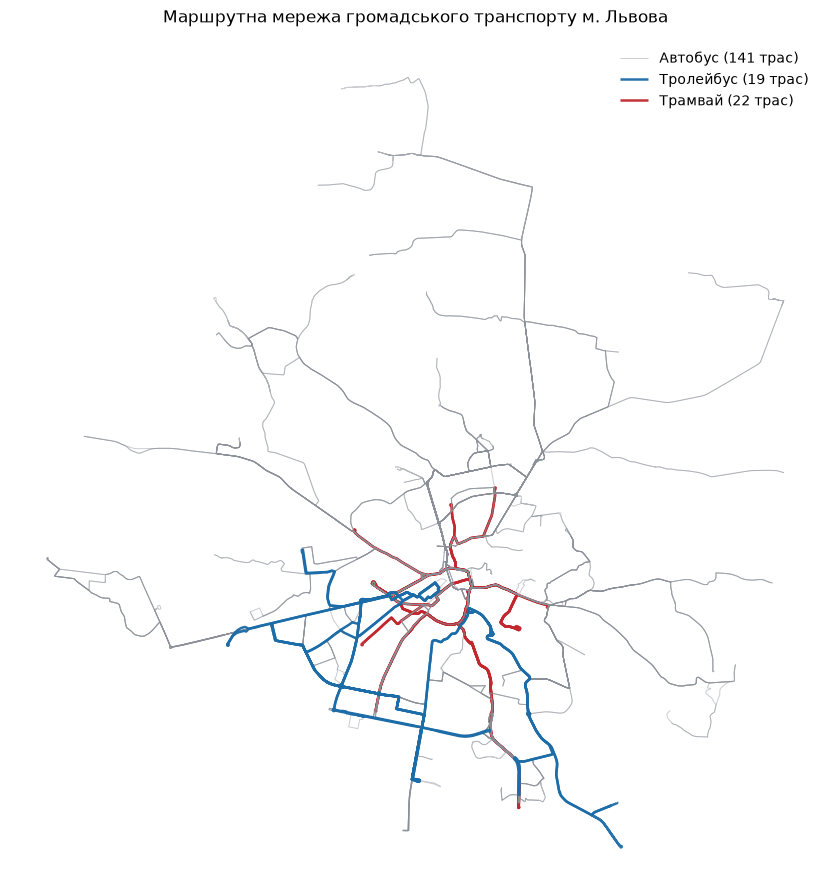

In [13]:
shapes_df = dataframes["shapes"]

# shape_id -> route_type (via trips; one shape may belong to only one route)
shape_to_type = (
    trips_df.join(routes_df, on="route_id", how="left")
    .select(["shape_id", "route_type"])
    .unique(subset=["shape_id"])
)

lines = (
    shapes_df.sort(["shape_id", "shape_pt_sequence"])
    .group_by("shape_id", maintain_order=True)
    .agg([pl.col("shape_pt_lon"), pl.col("shape_pt_lat")])
    .join(shape_to_type, on="shape_id", how="inner")
)

gdf = gpd.GeoDataFrame(
    {"shape_id": lines["shape_id"], "route_type": lines["route_type"]},
    geometry=[
        LineString(zip(lo, la))
        for lo, la in zip(lines["shape_pt_lon"], lines["shape_pt_lat"])
    ],
    crs="EPSG:4326",
)
gdf = gdf.to_crs(gdf.estimate_utm_crs())
print("Geometry CRS:", gdf.crs.name, "| Roads:", len(gdf))

fig, ax = plt.subplots(figsize=(11, 11))
for rt in (3, 11, 0): # trams & trolleys on top
    sub = gdf[gdf["route_type"] == rt]
    if len(sub):
        sub.plot(
            ax=ax,
            color=MODE_COLORS[rt],
            linewidth=0.7 if rt == 3 else 1.8,
            alpha=0.45 if rt == 3 else 0.95,
            label=f"{MODE_NAMES_UA[rt]} ({sub['shape_id'].nunique()} трас)",
            zorder=rt,
        )
ax.legend(loc="upper right", frameon=False)
ax.set_axis_off()
ax.set_title("Маршрутна мережа громадського транспорту м. Львова", pad=12)
fig.savefig(OUT / "network_map.png", dpi=300, bbox_inches="tight")
plt.show()

### Naive graph

In [14]:
stops_df = dataframes["stops"]

st = (
    stop_times_df.sort(["trip_id", "stop_sequence"])
    .with_columns(pl.col("stop_id").shift(-1).over("trip_id").alias("next_stop"))
    .drop_nulls("next_stop")
)

edges = st.group_by(["stop_id", "next_stop"]).agg(pl.len().alias("weight"))
G = nx.from_pandas_edgelist(
    edges.to_pandas(),
    "stop_id",
    "next_stop",
    edge_attr="weight",
    create_using=nx.DiGraph,
)

comps = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
print(f"Nodes: {G.number_of_nodes()}  Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.6f}")
print(f"Connected components: {len(comps)} | sizes: {[len(c) for c in comps[:10]]}")
print(f"Isolated stops (not in graph): {len(stops_df) - G.number_of_nodes()}")

Nodes: 1054  Edges: 1296
Density: 0.001168
Connected components: 1 | sizes: [1054]
Isolated stops (not in graph): 7


### Transfers between modes

count    1061.000000
mean       64.668578
std        79.520266
min         1.352238
25%        18.935728
50%        42.223027
75%        83.167212
max      1189.401488
Name: dist, dtype: float64

Stops that have a neighbor closer than 50 m: 609 out of 1061


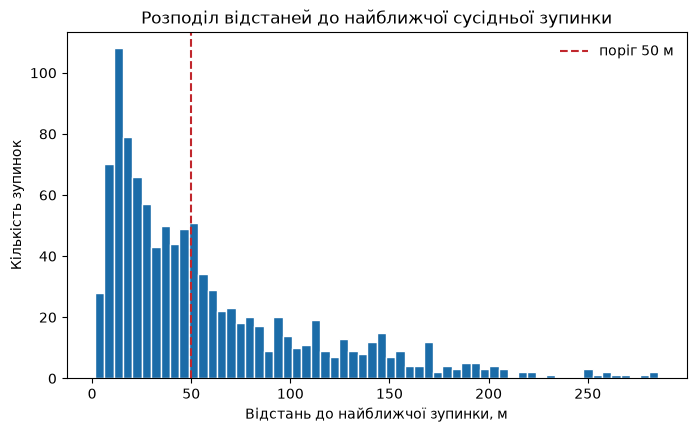

Stops: 1061 -> stations: 1059
Shortening: 0.2%
Cluster sizes:
1    1058
3       1
Name: count, dtype: int64

Biggest clusters:
     station_id                                     stop_name  stop_id
342         342  Лікувально-діагностичний центр "Сихів" (754)    45145
444         342  Лікувально-діагностичний центр "Сихів" (754)    44984
451         342  Лікувально-діагностичний центр "Сихів" (754)    44705

Station graph: 1052 nodes, 1296 edges
Connected components: 1 | sizes: [1052]


In [15]:
stops_gdf = gpd.GeoDataFrame(
    stops_df.select(["stop_id", "stop_name"]).to_pandas(),
    geometry=[Point(x, y) for x, y in zip(stops_df["stop_lon"], stops_df["stop_lat"])],
    crs="EPSG:4326",
).to_crs("EPSG:4326")
stops_gdf = stops_gdf.to_crs(stops_gdf.estimate_utm_crs())

# https://geopandas.org/en/stable/docs/reference/api/geopandas.sjoin_nearest.html
nearest = gpd.sjoin_nearest(
    stops_gdf, stops_gdf, how="left", distance_col="dist", exclusive=True
)
nearest = nearest.groupby("stop_id_left")["dist"].min()
print(nearest.describe(), end="\n\n")
print(
    f"Stops that have a neighbor closer than 50 m: {(nearest < 50).sum()} out of {len(nearest)}"
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(nearest[nearest < 300], bins=60, color="#1B6CA8", edgecolor="white")
ax.axvline(50, color="#C1272D", ls="--", lw=1.5, label="поріг 50 м")
ax.set_xlabel("Відстань до найближчої зупинки, м")
ax.set_ylabel("Кількість зупинок")
ax.set_title("Розподіл відстаней до найближчої сусідньої зупинки")
ax.legend(frameon=False)
fig.savefig(OUT / "nearest_stop_distance.png", dpi=300, bbox_inches="tight")
plt.show()

# Clustering: same name + distance < 50 m
# Ierarchical clustering with complete linkage: avoids chaining effect, unlike DBSCAN.
EPS_M = 50
stops_gdf["x"] = stops_gdf.geometry.x
stops_gdf["y"] = stops_gdf.geometry.y
labels, next_id = {}, 0

for name, grp in stops_gdf.groupby("stop_name", sort=False):
    if len(grp) == 1:
        labels[grp["stop_id"].iloc[0]] = next_id
        next_id += 1
        continue
    sub = fcluster(
        linkage(pdist(grp[["x", "y"]].values), method="complete"),
        t=EPS_M,
        criterion="distance",
    )
    for sid, c in zip(grp["stop_id"], sub):
        labels[sid] = next_id + int(c) - 1
    next_id += int(sub.max())

stops_gdf["station_id"] = stops_gdf["stop_id"].map(labels)
sizes = stops_gdf.groupby("station_id").size()
print(f"Stops: {len(stops_gdf)} -> stations: {stops_gdf['station_id'].nunique()}")
print(
    f"Shortening: {(1 - stops_gdf['station_id'].nunique() / len(stops_gdf)) * 100:.1f}%"
)
print("Cluster sizes:")
print(sizes.value_counts().sort_index(), end="\n\n")

print("Biggest clusters:")
print(
    stops_gdf[stops_gdf["station_id"].isin(sizes[sizes >= 3].index)]
    .sort_values("station_id")[["station_id", "stop_name", "stop_id"]]
    .head(20),
    end="\n\n",
)

# station_id -> stop_id mapping
s2st = dict(zip(stops_gdf["stop_id"], stops_gdf["station_id"]))
edges_st = (
    edges.with_columns(
        [
            pl.col("stop_id").replace_strict(s2st, default=None).alias("a"),
            pl.col("next_stop").replace_strict(s2st, default=None).alias("b"),
        ]
    )
    .filter(pl.col("a") != pl.col("b"))
    .group_by(["a", "b"])
    .agg(pl.col("weight").sum())
)

G2 = nx.from_pandas_edgelist(
    edges_st.to_pandas(), "a", "b", edge_attr="weight", create_using=nx.DiGraph
)
c2 = sorted(nx.weakly_connected_components(G2), key=len, reverse=True)
print(f"Station graph: {G2.number_of_nodes()} nodes, {G2.number_of_edges()} edges")
print(f"Connected components: {len(c2)} | sizes: {[len(c) for c in c2[:10]]}")